<a href="https://colab.research.google.com/github/AristidesAntonioOrellanaZelaya/2505442022_ORELLANA_ARISTIDES_CLAVE_E_PARCIAL_4/blob/main/Notebook/Ejercicio_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
url = "https://raw.githubusercontent.com/AristidesAntonioOrellanaZelaya/2505442022_ORELLANA_ARISTIDES_CLAVE_E_PARCIAL_4/refs/heads/main/Data/clave_E_agrupacion.csv"

df = pd.read_csv(url)

In [3]:
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,E-R0096,39,986,7.83,99.00,8.08,2,24
1,E-R0092,41,905,5.52,82.98,8.07,2,23
2,E-R0079,34,1109,7.17,65.25,8.46,0,13
3,E-R0019,32,618,2.57,25.75,5.09,12,21
4,E-R0174,49,1592,8.08,172.04,6.55,0,28


In [4]:
# VALIDACIÓN DEL DATASET

print("DIMENSIONES:")
print(df.shape)

print("\nCOLUMNAS:")
print(df.columns)

print("\nTIPOS DE DATOS:")
print(df.dtypes)

print("\nVALORES NULOS:")
print(df.isnull().sum())

print("\nDUPLICADOS:")
print(df.duplicated().sum())

DIMENSIONES:
(246, 8)

COLUMNAS:
Index(['registro_id', 'edad', 'ingresos', 'frecuencia_uso', 'gasto_promedio',
       'satisfaccion', 'reclamos', 'antiguedad_meses'],
      dtype='object')

TIPOS DE DATOS:
registro_id          object
edad                  int64
ingresos              int64
frecuencia_uso      float64
gasto_promedio      float64
satisfaccion        float64
reclamos              int64
antiguedad_meses      int64
dtype: object

VALORES NULOS:
registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        1
reclamos            0
antiguedad_meses    0
dtype: int64

DUPLICADOS:
0


In [17]:
# SELECCIÓN DE VARIABLES

variables = df.select_dtypes(include=np.number)

variables.head()

,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,39,986,7.83,99.00,8.08,2,24
1,41,905,5.52,82.98,8.07,2,23
2,34,1109,7.17,65.25,8.46,0,13
3,32,618,2.57,25.75,5.09,12,21
4,49,1592,8.08,172.04,6.55,0,28


In [16]:

# ELIMINAR VALORES NULOS

df = df.dropna()

print(df.isnull().sum())

registro_id         0
edad                0
ingresos            0
frecuencia_uso      0
gasto_promedio      0
satisfaccion        0
reclamos            0
antiguedad_meses    0
dtype: int64


In [18]:
# NORMALIZACIÓN

scaler = StandardScaler()

variables_escaladas = scaler.fit_transform(variables)

variables_escaladas

array([[ 0.09014777, -0.10734455,  0.85069781, ...,  0.60637779,
        -0.22240336,  0.49070717],
       [ 0.28473988, -0.29932838,  0.08247578, ...,  0.600971  ,
        -0.22240336,  0.41304357],
       [-0.39633249,  0.18418646,  0.6312058 , ...,  0.81183608,
        -1.20418396, -0.36359246],
       ...,
       [ 0.86851619,  1.59680824,  2.01799621, ...,  1.28763421,
        -0.71329366,  1.65566122],
       [ 0.47933198,  2.05899154,  1.70871202, ...,  1.1362439 ,
        -1.20418396,  1.65566122],
       [ 1.93877277,  1.74138866,  0.38843434, ...,  1.64448281,
        -1.20418396,  0.64603438]])

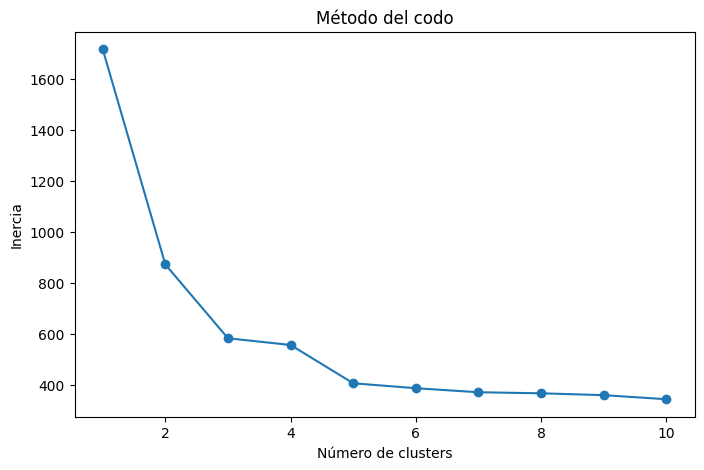

In [19]:
# MÉTODO DEL CODO

inercia = []

for k in range(1, 11):

    modelo = KMeans(
        n_clusters=k,
        random_state=42
    )

    modelo.fit(variables_escaladas)

    inercia.append(modelo.inertia_)

# Gráfico
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inercia, marker='o')

plt.title("Método del codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")

plt.show()

In [20]:
# K-MEANS

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

kmeans.fit(variables_escaladas)

clusters = kmeans.labels_

clusters

array([1, 1, 1, 0, 2, 0, 0, 2, 2, 1, 0, 0, 2, 1, 2, 0, 1, 2, 0, 1, 2, 0,
       0, 1, 2, 2, 0, 0, 0, 0, 0, 2, 2, 2, 0, 2, 1, 2, 1, 0, 1, 0, 0, 0,
       1, 0, 2, 2, 1, 0, 0, 1, 0, 0, 2, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 2, 1, 0, 1, 0, 1, 2, 1, 1, 0, 2, 1, 1, 0, 2, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 2, 2, 0, 0, 1, 1, 0, 1, 2, 1, 0, 0, 0, 0,
       0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 2, 0, 1, 1, 1, 1, 0, 2, 0, 1, 2, 0, 2, 0, 0,
       2, 1, 0, 0, 1, 1, 2, 1, 2, 2, 0, 0, 2, 0, 0, 1, 2, 2, 2, 0, 0, 0,
       0, 0, 1, 0, 2, 0, 0, 2, 2, 1, 0, 0, 0, 0, 1, 0, 0, 2, 1, 0, 2, 0,
       2, 2, 0, 0, 1, 0, 1, 1, 0, 2, 0, 2, 0, 0, 0, 2, 0, 1, 2, 2, 2, 1,
       1, 0, 0, 0, 2, 0, 1, 0, 0, 2, 0, 1, 2, 1, 2, 0, 0, 0, 2, 2, 1, 0,
       2, 2, 2], dtype=int32)

In [22]:
# AGREGAR CLUSTER

df['Cluster'] = clusters

df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses,Cluster
0,E-R0096,39,986,7.83,99.00,8.08,2,24,1
1,E-R0092,41,905,5.52,82.98,8.07,2,23,1
2,E-R0079,34,1109,7.17,65.25,8.46,0,13,1
3,E-R0019,32,618,2.57,25.75,5.09,12,21,0
4,E-R0174,49,1592,8.08,172.04,6.55,0,28,2


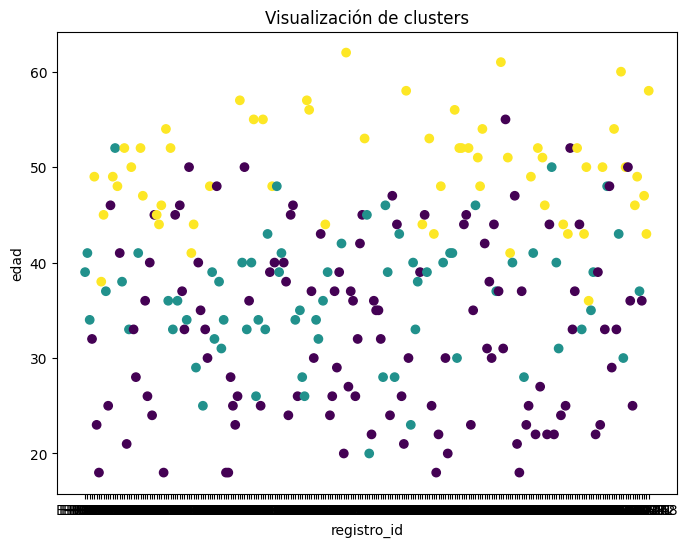

In [24]:
# VISUALIZACIÓN

plt.figure(figsize=(8,6))

plt.scatter(
    df.iloc[:,0],
    df.iloc[:,1],
    c=df['Cluster']
)

plt.title("Visualización de clusters")

plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])

plt.show()